In [1]:
!pip install gigachat

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import random
from gigachat import GigaChat
from getpass import getpass
import json

In [3]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [4]:
ACCESS_TOKEN = getpass("GigaChat access token: ")

GigaChat access token: ··········


In [125]:
POPULATION_SIZE = 16        # число архитектур в популяции
GENERATIONS = 60           # количество поколений
EPOCHS_PER_MODEL = 10      # эпох обучения для каждой модели
BATCH_SIZE = 64
ELITE_COUNT = 1            # топ-1 сохраняется без изменений
MUTATION_PROB = 0.7        # вероятность мутации для каждой особи (кроме элиты)

In [126]:
# Ограничения на архитектуру
MIN_NEURONS = 8
MAX_NEURONS = 128
MIN_HIDDEN_LAYERS = 1
MAX_HIDDEN_LAYERS = 3

In [127]:
# Размеры датасета
N_SAMPLES = 1000
N_FEATURES = 10
TRAIN_RATIO = 0.8

In [128]:
successful_mutations_history = []
llm_cache = {}

In [129]:
llm_cache.clear()

In [130]:
def llm_mutate(layer_sizes, activations, current_accuracy, generation=None):
    """
    Отправляет архитектуру в GigaChat и получает предложение по улучшению.
    Возвращает кортеж (new_layer_sizes, new_activations, explanation) или None при ошибке.
    """

    key = (tuple(layer_sizes), tuple(activations))
    if key in llm_cache:
        cached = llm_cache[key]
        print(f"  Использую кеш для {layer_sizes} (предыдущее предложение: {cached[0]})")
        return cached[0], cached[1], cached[2]

    giga = GigaChat(
        access_token=ACCESS_TOKEN,
        verify_ssl_certs=False,
        model='GigaChat-2'
    )

    arch_str = " -> ".join(map(str, layer_sizes))
    act_str = ", ".join(activations) if activations else "нет скрытых слоёв"
    hidden_count = len(layer_sizes) - 2

    train_pos_ratio = float(y_train.mean())
    val_size = len(val_dataset)

    prompt = f"""
Ты — эксперт по нейросетевым архитектурам для бинарной классификации.
Дана архитектура:
- Вход: {layer_sizes[0]} признаков
- Скрытые слои: {arch_str} (всего {hidden_count} скрытых слоёв)
- Активации скрытых слоёв: {act_str}
- Выход: 1 нейрон (сигмоида)

Текущая точность на валидации: {current_accuracy:.4f}
Размер обучающей выборки: {len(train_dataset)} объектов, доля положительных: {train_pos_ratio:.2f}
Размер валидационной выборки: {val_size} объектов

Задача: предложи ОДНО изменение архитектуры, которое может улучшить качество.
Варианты изменений:
- изменить число нейронов в любом скрытом слое (в пределах от {MIN_NEURONS} до {MAX_NEURONS})
- добавить новый скрытый слой (всего не более {MAX_HIDDEN_LAYERS})
- удалить один скрытый слой (если их больше {MIN_HIDDEN_LAYERS})
- заменить функцию активации (можно: relu, tanh, leaky_relu, elu)
- добавить Dropout (например, 0.2) после любого скрытого слоя (указывается в активациях как "dropout_0.2")
- добавить BatchNormalization (указывается как "batchnorm")

ВАЖНО: число активаций должно ровно совпадать с числом скрытых слоёв + число dropout/batchnorm вставляется как отдельная активация.
Например, если слоёв [10, 32, 64, 1] (2 скрытых слоя) и мы добавляем Dropout после первого, то активации: ["relu", "dropout_0.2", "tanh"].

Ответь строго в формате JSON:
{{
  "new_layer_sizes": [вход, ... , выход],
  "new_activations": ["активация1", "активация2", ...],
  "explanation": "кратко, почему это улучшит (1-2 предложения)"
}}
Только JSON, без пояснений.
"""

    response = giga.chat({
        "messages": [
            {"role": "system", "content": "Ты — полезный ассистент, отвечающий только JSON."},
            {"role": "user", "content": prompt}
        ]
    })
    raw = response.choices[0].message.content
    print("  LLM ответил:", raw[:200] + "..." if len(raw) > 200 else raw)

    start = raw.find('{')
    end = raw.rfind('}') + 1
    if start == -1 or end == 0:
        return None
    data = json.loads(raw[start:end])
    new_sizes = data.get("new_layer_sizes")
    new_acts = data.get("new_activations")
    explanation = data.get("explanation", "")

    # Валидация с автоматическим исправлением числа активаций
    if not new_sizes or not new_acts:
        return None

    expected_acts = len(new_sizes) - 1  # число скрытых слоёв (без выходного)
    if len(new_acts) != expected_acts:
        print(f"Несоответствие: слоёв {len(new_sizes)}, активаций {len(new_acts)} → исправляем до {expected_acts}")
        if len(new_acts) > expected_acts:
            new_acts = new_acts[:expected_acts]  # обрезаем лишние
        else:
            # дополняем relu
            while len(new_acts) < expected_acts:
                new_acts.append("relu")
        print(f"Исправленные активации: {new_acts}")

    # Проверка входного и выходного размеров
    if new_sizes[0] != layer_sizes[0] or new_sizes[-1] != layer_sizes[-1]:
        print(f"Изменены вход или выход")
        return None

    # Проверка размеров скрытых слоёв
    for size in new_sizes[1:-1]:
        if size < MIN_NEURONS or size > MAX_NEURONS:
            print(f"Нейрон вне допустимого диапазона: {size}")
            return None

    # Проверка числа скрытых слоёв
    if len(new_sizes) - 2 > MAX_HIDDEN_LAYERS or len(new_sizes) - 2 < MIN_HIDDEN_LAYERS:
        print(f"Число скрытых слоёв вне диапазона")
        return None

    # Сохраняем в кеш
    llm_cache[key] = (new_sizes, new_acts, explanation)
    return new_sizes, new_acts, explanation

In [131]:
def generate_synthetic_data(n_samples=1000, n_features=10):
    """Генерируем данные с нелинейной зависимостью"""
    X = np.random.randn(n_samples, n_features)
    # Истинная функция: комбинация синусов и линейных членов
    y_true = (np.sin(X[:, 0] * 2) + np.cos(X[:, 1] * 1.5) +
              0.5 * X[:, 2] - 0.3 * X[:, 3] + np.random.randn(n_samples) * 0.3)
    y = (y_true > 0).astype(np.float32)
    return X.astype(np.float32), y.reshape(-1, 1)

In [132]:
X, y = generate_synthetic_data(N_SAMPLES, N_FEATURES)

In [133]:
split = int(N_SAMPLES * TRAIN_RATIO)
X_train, y_train = X[:split], y[:split]
X_val, y_val = X[split:], y[split:]

In [134]:
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [135]:
print(f"Тренировочных объектов: {len(train_dataset)}")
print(f"Валидационных объектов: {len(val_dataset)}")
print(f"Число признаков: {N_FEATURES}")

Тренировочных объектов: 800
Валидационных объектов: 200
Число признаков: 10


In [136]:
class DynamicModel(nn.Module):
    """Модель с динамической архитектурой (список слоёв)"""
    def __init__(self, layer_sizes, activations):
        """
        layer_sizes: list of int, [input, hidden1, hidden2, ..., output]
        activations: list of str, активации для каждого скрытого слоя (длина = len(layer_sizes)-2)
        """
        super().__init__()
        self.layers = nn.ModuleList()
        self.activations = []

        for i in range(len(layer_sizes) - 1):
            in_dim = layer_sizes[i]
            out_dim = layer_sizes[i+1]
            self.layers.append(nn.Linear(in_dim, out_dim))
            if i < len(layer_sizes) - 2:
                # добавляем активацию для скрытых слоёв
                if activations[i] == 'relu':
                    self.activations.append(nn.ReLU())
                elif activations[i] == 'tanh':
                    self.activations.append(nn.Tanh())
                else:
                    self.activations.append(nn.ReLU())  # fallback
            else:
                self.activations.append(None)  # для выходного слоя

    def forward(self, x):
        for layer, act in zip(self.layers, self.activations):
            x = layer(x)
            if act is not None:
                x = act(x)
        return torch.sigmoid(x)  # для бинарной классификации

In [137]:
def train_and_evaluate(layer_sizes, activations, train_loader, val_loader, epochs=EPOCHS_PER_MODEL):
    """
    Обучает модель на train_loader, возвращает accuracy на val_loader.
    Всегда использует SGD с lr=0.01.
    """
    model = DynamicModel(layer_sizes, activations)
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()

    # Оценка на валидации
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            pred = model(X_batch)
            predicted = (pred > 0.5).float()
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
    accuracy = correct / total
    return accuracy, model

In [138]:
def random_architecture(input_dim, output_dim=1):
    """Создаёт случайную архитектуру с 1-3 скрытыми слоями"""
    n_hidden = random.randint(MIN_HIDDEN_LAYERS, MAX_HIDDEN_LAYERS)
    layer_sizes = [input_dim]
    activations = []
    for _ in range(n_hidden):
        size = random.randint(MIN_NEURONS, MAX_NEURONS)
        layer_sizes.append(size)
        activation = random.choice(['relu', 'tanh'])
        activations.append(activation)
    layer_sizes.append(output_dim)
    return layer_sizes, activations

In [139]:
def mutate_architecture(layer_sizes, activations):
    """
    Применяет одну случайную мутацию:
    - change_neurons: меняет размер скрытого слоя на ±8
    - add_layer: добавляет новый скрытый слой со случайным размером
    - remove_layer: удаляет случайный скрытый слой (если их больше 1)
    Возвращает новую пару (layer_sizes, activations) или None, если мутация невозможна.
    """
    # Определяем индексы скрытых слоёв (между входом и выходом)
    hidden_indices = list(range(1, len(layer_sizes) - 1))
    if not hidden_indices:
        return None  # нет скрытых слоёв — мутация невозможна

    mutation_type = random.choice(['change_neurons', 'add_layer', 'remove_layer'])
    new_sizes = layer_sizes.copy()
    new_activations = activations.copy()

    if mutation_type == 'change_neurons':
        idx = random.choice(hidden_indices)
        delta = random.choice([-8, 8])
        new_size = new_sizes[idx] + delta
        new_size = max(MIN_NEURONS, min(MAX_NEURONS, new_size))
        if new_size == new_sizes[idx]:
            return None  # без изменений
        new_sizes[idx] = new_size

    elif mutation_type == 'add_layer':
        if len(hidden_indices) >= MAX_HIDDEN_LAYERS:
            return None
        # Вставляем новый слой после случайного существующего скрытого слоя
        pos = random.randint(0, len(hidden_indices))
        # pos — индекс в списке hidden_indices, определяем позицию в layer_sizes
        insert_idx = hidden_indices[pos] if pos < len(hidden_indices) else len(new_sizes)-1
        new_size = random.randint(MIN_NEURONS, MAX_NEURONS)
        new_sizes.insert(insert_idx, new_size)
        # вставляем активацию на ту же позицию (перед вставленной)
        new_act = random.choice(['relu', 'tanh'])
        new_activations.insert(pos, new_act)

    elif mutation_type == 'remove_layer':
        if len(hidden_indices) <= MIN_HIDDEN_LAYERS:
            return None
        # Удаляем случайный скрытый слой
        pos = random.randint(0, len(hidden_indices)-1)
        remove_idx = hidden_indices[pos]
        del new_sizes[remove_idx]
        del new_activations[pos]

    return new_sizes, new_activations

In [140]:
llm_cache.clear()

In [141]:
TOP_K = min(12, POPULATION_SIZE)

In [142]:
population = []
for _ in range(POPULATION_SIZE):
    arch, act = random_architecture(N_FEATURES, 1)
    population.append((arch, act))

In [143]:
best_acc_history = []
avg_acc_history = []
llm_success_count = 0
failed_llm_count = 0

In [144]:
best_global_arch = None
best_global_act = None
best_global_acc = -1.0

In [145]:
USE_LLM = True

In [146]:
for gen in range(GENERATIONS):
    print(f"\n{'='*50}")
    print(f"Поколение {gen+1}/{GENERATIONS}")
    print(f"{'='*50}")
    fitnesses = []
    models = []

    # Оценка каждой особи
    for idx, (arch, act) in enumerate(population):
        print(f"Особь {idx+1}: слои {arch} | активации: {act}")
        acc, model = train_and_evaluate(arch, act, train_loader, val_loader)
        fitnesses.append(acc)
        models.append(model)
        print(f"Точность: {acc:.4f}")

    # Обновляем глобальный лучший результат
    current_best_idx = np.argmax(fitnesses)
    current_best_acc = fitnesses[current_best_idx]
    if current_best_acc > best_global_acc:
        best_global_acc = current_best_acc
        best_global_arch = population[current_best_idx][0]
        best_global_act = population[current_best_idx][1]
        print(f"Новая глобально лучшая точность: {best_global_acc:.4f} (архитектура {best_global_arch})")

    # Ранговый отбор
    sorted_indices = np.argsort(fitnesses)[::-1]
    ranks = np.arange(POPULATION_SIZE, 0, -1)
    weights = ranks / ranks.sum()

    # --- LLM-мутации для топ-K особей ---
    if USE_LLM:
        print(f"\nЗапрос к GigaChat для топ-{TOP_K} особей...")
        any_success = False
        for rank in range(TOP_K):
            idx = sorted_indices[rank]
            arch, act = population[idx]
            acc = fitnesses[idx]
            print(f"Особь #{rank+1}: {arch} (acc={acc:.4f})")
            result = llm_mutate(arch, act, acc, generation=gen+1)
            if result is not None:
                if len(result) == 3:
                    new_arch, new_act, explanation = result
                elif len(result) == 2:
                    new_arch, new_act = result
                    explanation = ""
                else:
                    print(f"Неожиданный формат ответа, пропускаем")
                    continue

                # Проверка на 5 эпохах (для большей точности)
                test_acc, _ = train_and_evaluate(new_arch, new_act, train_loader, val_loader, epochs=5)
                improvement = test_acc - acc
                if improvement >= 0.001:
                    worst_idx = sorted_indices[-1]
                    population[worst_idx] = (new_arch, new_act)
                    llm_success_count += 1
                    any_success = True
                    failed_llm_count = 0
                    print(f"✅ LLM улучшил: {new_arch} (прирост +{improvement:.4f})")
                    if explanation:
                        print(f"       Объяснение: {explanation}")
                else:
                    print(f"LLM предложил, но прирост {improvement:.4f} — отклоняем")
                    failed_llm_count += 1
            else:
                print("LLM не вернул мутацию, пропускаем")
                failed_llm_count += 1

        if failed_llm_count >= 10:
            print(f"Слишком много неудачных LLM-мутаций ({failed_llm_count}), очищаем кеш")
            llm_cache.clear()
            failed_llm_count = 0

    # Формируем новую популяцию
    new_population = []
    # Элитизм
    for i in range(ELITE_COUNT):
        best_idx = sorted_indices[i]
        new_population.append(population[best_idx])

    # Отбор родителей для случайных мутаций
    parents = []
    for _ in range(POPULATION_SIZE - ELITE_COUNT):
        parent_idx = np.random.choice(POPULATION_SIZE, p=weights)
        parents.append(population[parent_idx])

    # Случайные мутации для оставшихся
    for parent in parents:
        if random.random() < MUTATION_PROB:
            child = mutate_architecture(parent[0], parent[1])
            if child is not None:
                new_population.append(child)
            else:
                new_population.append(parent)
        else:
            new_population.append(parent)

    # Заполняем, если не хватило
    while len(new_population) < POPULATION_SIZE:
        arch, act = random_architecture(N_FEATURES, 1)
        new_population.append((arch, act))

    population = new_population

    # Логирование
    best_acc = max(fitnesses)
    avg_acc = np.mean(fitnesses)
    best_acc_history.append(best_acc)
    avg_acc_history.append(avg_acc)
    print(f"\nЛучшая точность в поколении: {best_acc:.4f}")
    print(f"Средняя точность: {avg_acc:.4f}")
    print(f"Лучшая архитектура сейчас: {population[sorted_indices[0]][0]}")

Выходные данные были обрезаны до нескольких последних строк (5000).
  Использую кеш для [10, 112, 1] (предыдущее предложение: [10, 32, 1])
LLM предложил, но прирост -0.1200 — отклоняем
Особь #7: [10, 128, 1] (acc=0.6650)
  LLM ответил: {
  "new_layer_sizes": [10, 64, 1],
  "new_activations": ["tanh", "tanh", "sigmoid"],
  "explanation": "Уменьшение числа нейронов во втором скрытом слое до 64 может снизить переобучение и повысить обо...
Несоответствие: слоёв 3, активаций 3 → исправляем до 2
Исправленные активации: ['tanh', 'tanh']
LLM предложил, но прирост -0.0100 — отклоняем
Особь #8: [10, 94, 1] (acc=0.6600)
  Использую кеш для [10, 94, 1] (предыдущее предложение: [10, 64, 1])
LLM предложил, но прирост -0.0250 — отклоняем
Особь #9: [10, 109, 74, 1] (acc=0.6600)
  LLM ответил: {
  "new_layer_sizes": [10, 64, 32, 1],
  "new_activations": ["tanh", "tanh", "sigmoid"],
  "explanation": "Увеличение числа нейронов в скрытых слоях позволяет модели лучше аппроксимировать сложную гр...
LLM пред

In [147]:
final_fitnesses = []
for arch, act in population:
    acc, _ = train_and_evaluate(arch, act, train_loader, val_loader)
    final_fitnesses.append(acc)
best_idx = np.argmax(final_fitnesses)
best_arch = population[best_idx][0]
best_act = population[best_idx][1]
best_final_acc = final_fitnesses[best_idx]

In [148]:
print("\n" + "="*50)
print(f"Лучшая найденная архитектура: слои {best_arch}")
print(f"Активации: {best_act}")
print(f"Финальная точность на валидации: {best_final_acc:.4f}")
print(f"Успешных LLM-мутаций: {llm_success_count}")
print("="*50)


Лучшая найденная архитектура: слои [10, 64, 1]
Активации: ['tanh', 'tanh']
Финальная точность на валидации: 0.7150
Успешных LLM-мутаций: 119


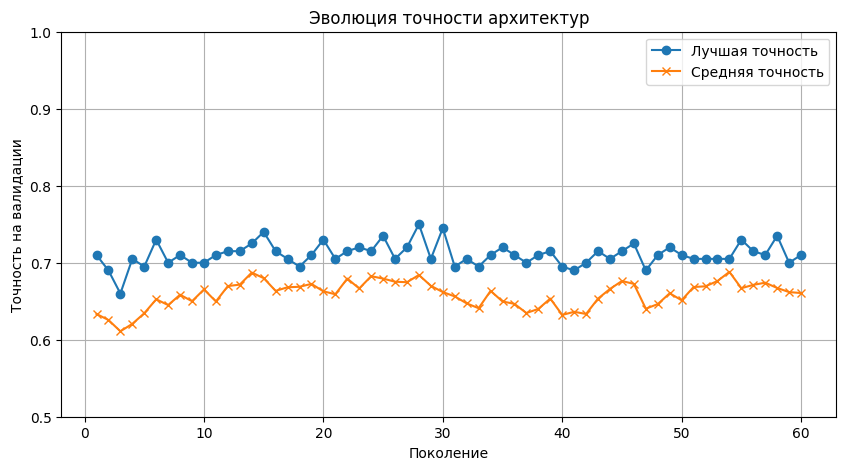

In [149]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, GENERATIONS+1), best_acc_history, label='Лучшая точность', marker='o')
plt.plot(range(1, GENERATIONS+1), avg_acc_history, label='Средняя точность', marker='x')
plt.xlabel('Поколение')
plt.ylabel('Точность на валидации')
plt.title('Эволюция точности архитектур')
plt.legend()
plt.grid(True)
plt.ylim(0.5, 1.0)
plt.show()

In [150]:
print("\nИтоговая лучшая архитектура:")
print(f"  Слои: {best_arch}")
print(f"  Активации: {best_act}")
print(f"  Точность: {best_final_acc:.4f}")


Итоговая лучшая архитектура:
  Слои: [10, 64, 1]
  Активации: ['tanh', 'tanh']
  Точность: 0.7150


In [151]:
print(f"\n🏆 Глобально лучшая архитектура за всё время: слои {best_global_arch}")
print(f"   Активации: {best_global_act}")
print(f"   Точность: {best_global_acc:.4f}")


🏆 Глобально лучшая архитектура за всё время: слои [10, 128, 1]
   Активации: ['tanh', 'tanh']
   Точность: 0.7500
